## Importing Libraries


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score,KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

### Importing Dataset

In [5]:
from google.cloud import bigquery

client = bigquery.Client()

query = """
SELECT *
FROM `root-anvil-474411-k5.aus_auto_silver.stg_vehicle_listings`
"""

df = client.query(query).to_dataframe()
df.head()

,listing_id,brand,vehicle_year,model,car_suv,title,used_or_new,transmission,drive_type,fuel_type,...,colour_ext_int_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour
0,05105c04080911debe87b53453aae2b2,Mitsubishi,2020,Express,Commercial,2020 Mitsubishi Express GLX LWB,USED,Automatic,Rear,Diesel,...,White / -,40990,22070,4,7.3,4,3,Mount Gravatt,QLD,White
1,096df010436890f06d4dac8326f874c8,BMW,2020,X2,SUV,2020 BMW X2 Sdrive20I M Sport,USED,Automatic,Front,Premium,...,Black / Black,48888,28164,4,6.0,4,5,Carlton,NSW,Black
2,0a859ca732d22b394343743c2cc606e6,Audi,2011,A4,Wagon,2011 Audi A4 2.0 Tfsi Avant Quattro,USED,Automatic,AWD,Premium,...,Blue / -,13990,165654,4,7.7,4,5,Morayfield,QLD,Blue
3,17d6f99300f3755bace466dc2dbd1be8,Mercedes-Benz,2020,C200,Convertible,2020 Mercedes-Benz C200,USED,Automatic,Rear,Unleaded,...,Blue / Beige,67990,36375,4,7.6,2,4,Bentley,WA,Blue
4,1a4df52d5bdcb5b65191db8c61c9e5fc,Holden,2006,Astra,Hatchback,2006 Holden Astra CDX,USED,Automatic,Front,Unleaded,...,Grey / -,5990,127968,4,8.2,5,5,Lansvale,NSW,Grey


In [6]:
df.tail()

,listing_id,brand,vehicle_year,model,car_suv,title,used_or_new,transmission,drive_type,fuel_type,...,colour_ext_int_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour
16051,42adeb6acd7a95700dd8fec33fb0471f,Toyota,2016,Yaris,Hatchback,2016 Toyota Yaris Ascent,USED,Automatic,Front,Unleaded,...,White / -,16950,116052,4,6.3,5,5,Granville,NSW,White
16052,ed067369e9c8b76943d463c9e19c24db,Toyota,2020,Yaris,Hatchback,2020 Toyota Yaris Ascent Sport,USED,Automatic,Front,Unleaded,...,Blue / Black,29990,8321,3,4.9,5,5,Pakenham,VIC,Blue
16053,28c25640a1fc4bb93fb3784199788e69,Toyota,2022,Yaris,SUV,2022 Toyota Yaris Cross Urban Hybrid,USED,Automatic,AWD,Hybrid,...,Gold / Dark Brown F,49990,1492,3,4.0,4,5,Kedron,QLD,Gold
16054,cd90ef54dfeaba10c578d9d4fb24c834,Toyota,2014,Yaris,Hatchback,2014 Toyota Yaris YR,USED,Automatic,Front,Unleaded,...,Blue / -,18599,92452,4,6.3,5,5,Garbutt,QLD,Blue
16055,4667c1db78a24ef06260811d7b04e3b2,Toyota,2020,Yaris,Hatchback,2020 Toyota Yaris SX,USED,Automatic,Front,Unleaded,...,Silver / Black,33990,16852,3,4.9,5,5,Pakenham,VIC,Silver


## Exploring the Dataset

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16056 entries, 0 to 16055
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   listing_id                16056 non-null  object 
 1   brand                     16056 non-null  object 
 2   vehicle_year              16056 non-null  Int64  
 3   model                     16056 non-null  object 
 4   car_suv                   16053 non-null  object 
 5   title                     16056 non-null  object 
 6   used_or_new               16056 non-null  object 
 7   transmission              15841 non-null  object 
 8   drive_type                16056 non-null  object 
 9   fuel_type                 15514 non-null  object 
 10  body_type                 15788 non-null  object 
 11  engine_raw                14431 non-null  object 
 12  location_raw              16056 non-null  object 
 13  colour_ext_int_raw        16056 non-null  object 
 14  price 

### Dedeupliication

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.drop_duplicates(inplace=True)

### Dropping Redundant Features

In [12]:
df=df.drop(['colour_ext_int_raw','car_suv','model','title'],axis=1)

### Replace Undefined Values 

In [13]:
df.replace(['-','POA','- / -'],np.nan,inplace=True)

In [14]:
df.isnull().sum()

listing_id                     0
brand                          0
vehicle_year                   0
used_or_new                    0
transmission                 215
drive_type                     0
fuel_type                    542
body_type                    268
engine_raw                  1625
location_raw                   0
price                          0
kilometres                     0
engine_cylinders            1625
fuel_consumption_l_100km    1648
doors                       1556
seats                       1648
city                           0
state                          0
exterior_colour              391
dtype: int64

## Outlier Analysis

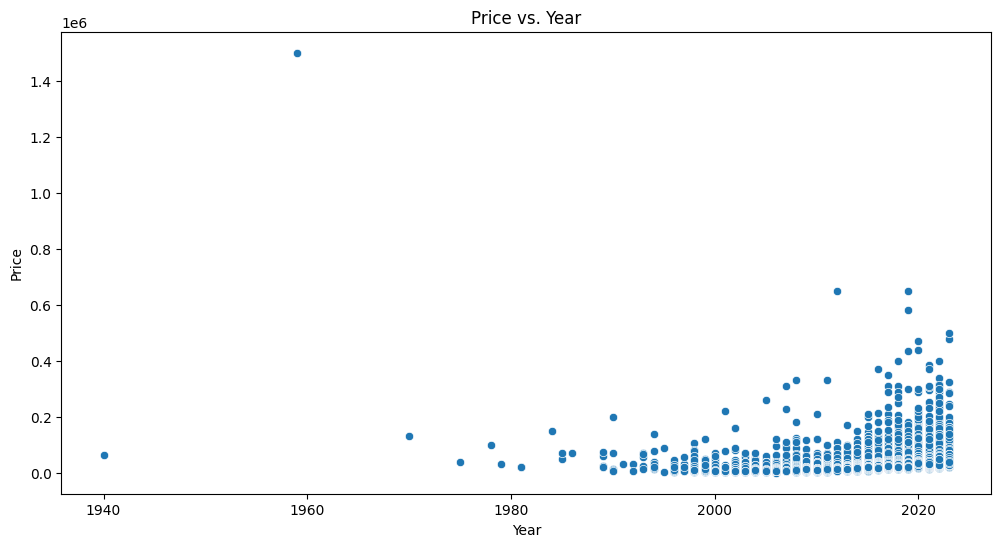

In [17]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=df['vehicle_year'], y=df['price'])
plt.title('Price vs. Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.show()

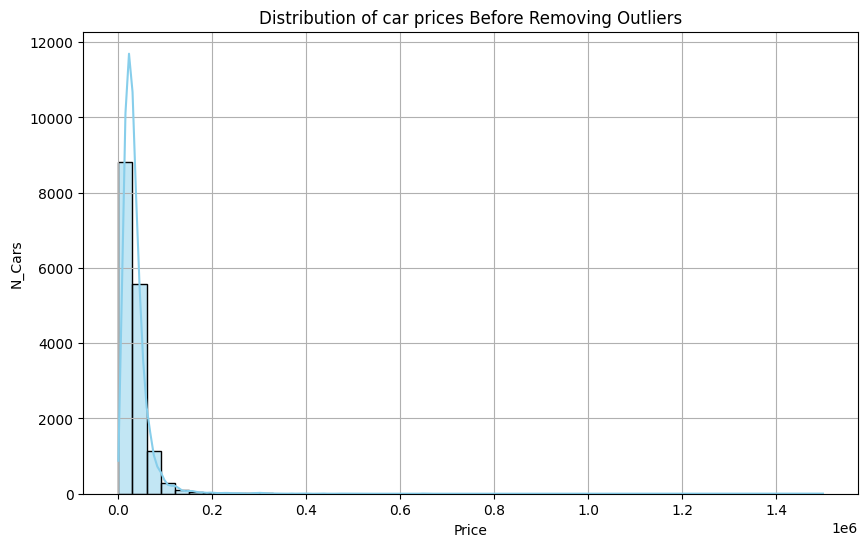

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of car prices Before Removing Outliers")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

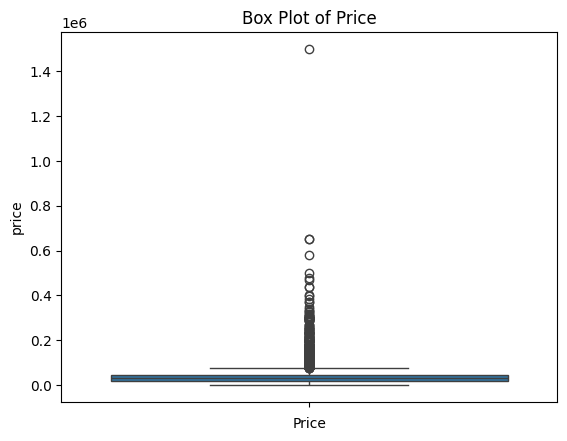

In [19]:
sns.boxplot(df['price'])
plt.title('Box Plot of Price')
plt.xlabel('Price')
plt.show()

#### Ignoring Data Outside IQR

outlier percentage 5.39%


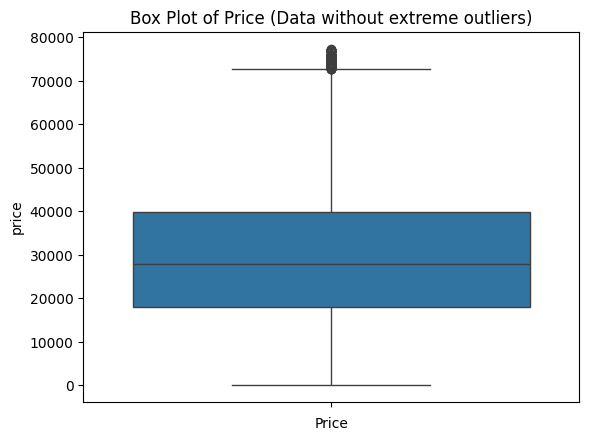

In [24]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df)) * 100
print(f"outlier percentage {outlier_percentage:.2f}%")
df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
sns.boxplot(df['price'])
plt.title('Box Plot of Price (Data without extreme outliers)')
plt.xlabel('Price')
plt.show()

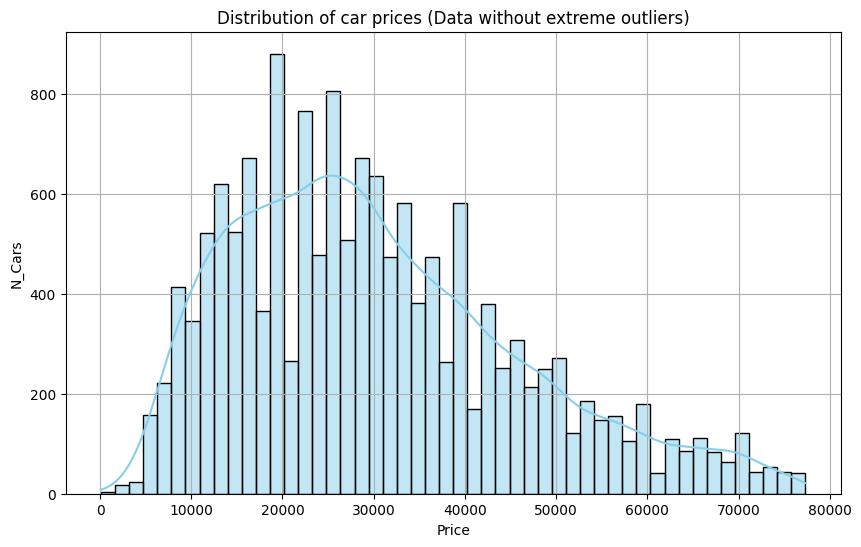

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of car prices (Data without extreme outliers)")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

### Handling Outliers WRT FuelConsumption

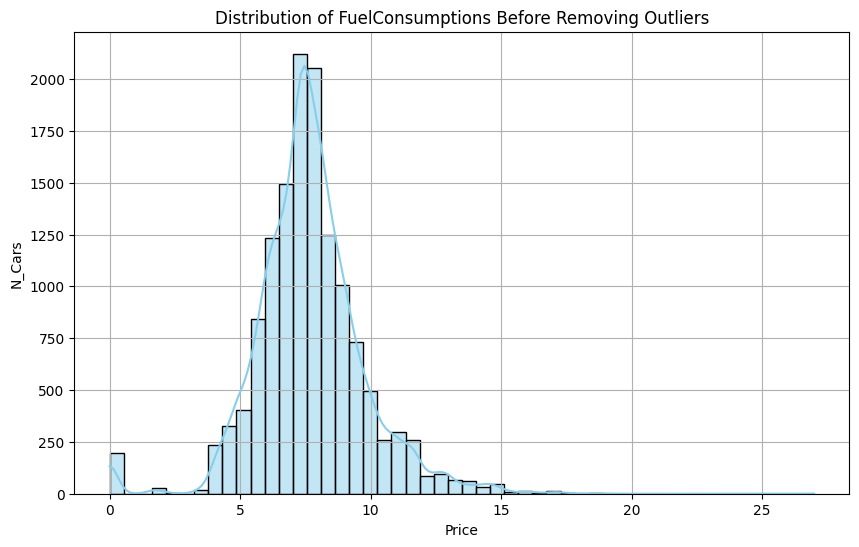

In [26]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fuel_consumption_l_100km'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of FuelConsumptions Before Removing Outliers")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

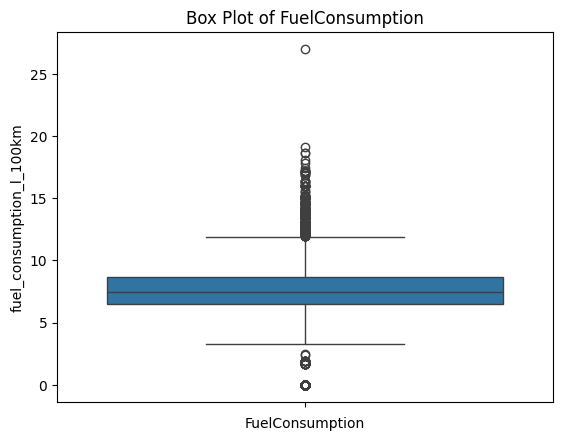

In [27]:
sns.boxplot(df['fuel_consumption_l_100km'])
plt.title('Box Plot of FuelConsumption')
plt.xlabel('FuelConsumption')
plt.show()

outlier percentage 0.42%


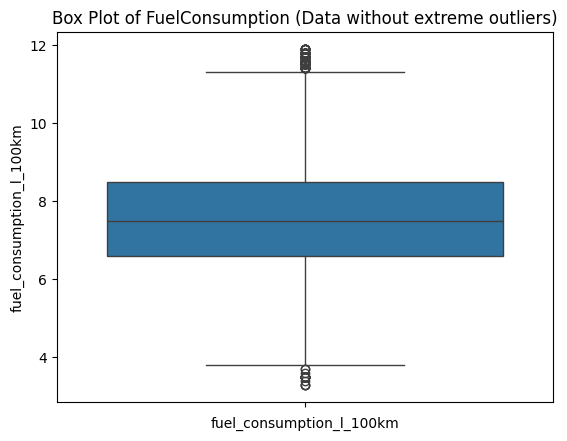

In [28]:
Q1 = df['fuel_consumption_l_100km'].quantile(0.25)
Q3 = df['fuel_consumption_l_100km'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['fuel_consumption_l_100km'] < lower_bound) | (df['fuel_consumption_l_100km'] > upper_bound)]
outlier_percentage = (len(outliers) / len(df)) * 10
print(f"outlier percentage {outlier_percentage:.2f}%")
df = df[(df['fuel_consumption_l_100km'] >= lower_bound) & (df['fuel_consumption_l_100km'] <= upper_bound)]
sns.boxplot(df['fuel_consumption_l_100km'])
plt.title('Box Plot of FuelConsumption (Data without extreme outliers)')
plt.xlabel('fuel_consumption_l_100km')
plt.show()

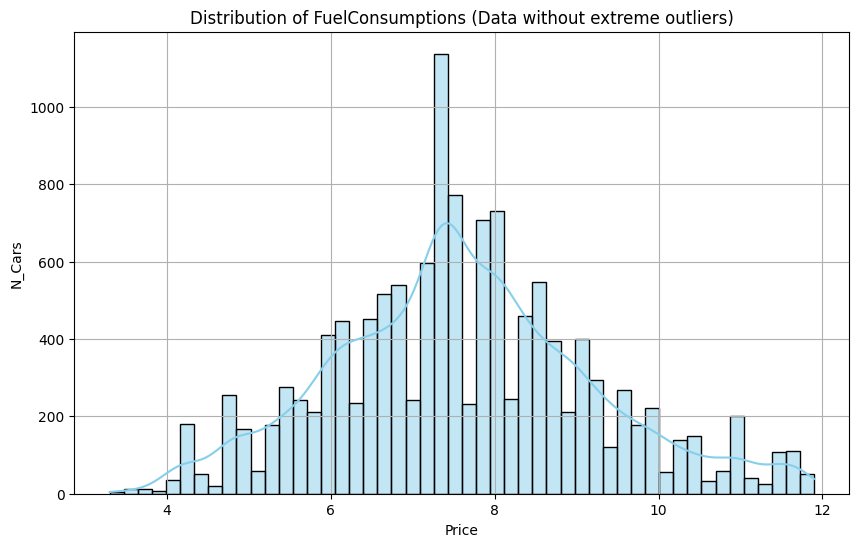

In [30]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fuel_consumption_l_100km'], kde=True, bins=50, color='skyblue')
plt.title("Distribution of FuelConsumptions (Data without extreme outliers)")
plt.xlabel("Price")
plt.ylabel("N_Cars")
plt.grid(True)
plt.show()

### Categorical Encoding

In [32]:
df=pd.get_dummies(df,columns=['used_or_new', 'transmission'], drop_first=True,dtype=int)

In [33]:
df.head()

,listing_id,brand,vehicle_year,drive_type,fuel_type,body_type,engine_raw,location_raw,price,kilometres,engine_cylinders,fuel_consumption_l_100km,doors,seats,city,state,exterior_colour,used_or_new_NEW,used_or_new_USED,transmission_Manual
0,05105c04080911debe87b53453aae2b2,Mitsubishi,2020,Rear,Diesel,Commercial,"4 cyl, 2 L","Mount Gravatt, QLD",40990,22070,4,7.3,4,3,Mount Gravatt,QLD,White,0,1,0
1,096df010436890f06d4dac8326f874c8,BMW,2020,Front,Premium,SUV,"4 cyl, 2 L","Carlton, NSW",48888,28164,4,6.0,4,5,Carlton,NSW,Black,0,1,0
2,0a859ca732d22b394343743c2cc606e6,Audi,2011,AWD,Premium,Wagon,"4 cyl, 2 L","Morayfield, QLD",13990,165654,4,7.7,4,5,Morayfield,QLD,Blue,0,1,0
3,17d6f99300f3755bace466dc2dbd1be8,Mercedes-Benz,2020,Rear,Unleaded,Convertible,"4 cyl, 2 L","Bentley, WA",67990,36375,4,7.6,2,4,Bentley,WA,Blue,0,1,0
4,1a4df52d5bdcb5b65191db8c61c9e5fc,Holden,2006,Front,Unleaded,Hatchback,"4 cyl, 1.8 L","Lansvale, NSW",5990,127968,4,8.2,5,5,Lansvale,NSW,Grey,0,1,0


In [34]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('price')
categorical_columns = df.select_dtypes(include=['object']).columns

In [35]:
for col in categorical_columns:
    print(f"\n column: {col}")
    print(df[col].value_counts())
    print(f"number of class = {df[col].nunique()}\n")


 column: listing_id
listing_id
4667c1db78a24ef06260811d7b04e3b2    1
05105c04080911debe87b53453aae2b2    1
096df010436890f06d4dac8326f874c8    1
0a859ca732d22b394343743c2cc606e6    1
17d6f99300f3755bace466dc2dbd1be8    1
                                   ..
31b9d75f0e0664212070b45cb577c6d8    1
31037c675f15011f9f80dca0885d3bf7    1
2f3ee67c67c926b61b872b287cc52409    1
2b91897c19e2ee5e7fad774166e53813    1
1f28774028eff6919001c25637bfc9ab    1
Name: count, Length: 13032, dtype: int64
number of class = 13032


 column: brand
brand
Toyota           2013
Hyundai          1129
Mazda            1020
Mitsubishi        922
Holden            894
Ford              850
Nissan            771
Kia               754
Volkswagen        732
Subaru            516
Mercedes-Benz     402
Audi              357
BMW               330
Honda             318
Suzuki            243
Jeep              227
MG                206
Isuzu             174
GWM               150
Renault           150
Land              129


### Ignoring all the rare categories

In [38]:
def drop_rare_categories(df, column, threshold=10):
    value_counts = df[column].value_counts()
    rare_categories = value_counts[value_counts < threshold].index
    df_filtered = df[~df[column].isin(rare_categories)]
    return df_filtered

for col in ['brand', 'fuel_type', 'state', 'body_type']:
    df = drop_rare_categories(df, column=col)

In [40]:
for col in numeric_columns:
    print(f"\n column: {col}")
    print(df[col].value_counts())
    print(f"number of class = {df[col].nunique()}\n")


 column: vehicle_year
vehicle_year
2018    1412
2019    1306
2017    1144
2016     991
2020     976
2015     944
2021     922
2022     893
2014     744
2013     731
2012     581
2023     486
2011     418
2010     346
2009     270
2008     222
2007     185
2006     125
2005      99
2004      54
2003      27
2002      23
2000      20
2001      11
1999      11
1998       5
1996       3
1997       2
1990       1
1989       1
1995       1
Name: count, dtype: Int64
number of class = 31


 column: kilometres
kilometres
10        92
15        56
7         52
20        51
12        30
          ..
116061     1
112220     1
22327      1
47799      1
169979     1
Name: count, Length: 11771, dtype: Int64
number of class = 11771


 column: engine_cylinders
engine_cylinders
4    10696
6     1474
5      390
3      291
8      100
2        3
Name: count, dtype: Int64
number of class = 6


 column: fuel_consumption_l_100km
fuel_consumption_l_100km
7.4    695
7.9    473
7.3    439
8.1    416
7.5    390


### Calculating car age

In [42]:
df['CarAge'] = 2025 - df['vehicle_year']
df.drop('vehicle_year', axis=1, inplace=True)

### Segmentation (Binning)

In [44]:
def door_category(d):
    if d <= 3:
        return 'Small'
    elif d <= 5:
        return 'Standard'
    else:
        return 'Large'

df['DoorCategory'] = df['doors'].apply(door_category)
df.drop('doors', axis=1, inplace=True)


def seat_category(s):
    if s <= 2:
        return 'Small'
    elif s <= 5:
        return 'Standard'
    elif s <= 7:
        return 'Family'
    else:
        return 'Large'

df['SeatCategory'] = df['seats'].apply(seat_category)
df.drop('seats', axis=1, inplace=True)

In [57]:
df=df.drop('listing_id',axis=1)

In [64]:
df=df.drop('engine_raw',axis=1)

In [70]:
df=df.drop('location_raw',axis=1)

In [76]:
df=df.drop('city',axis=1)

In [77]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('price')
categorical_columns = df.select_dtypes(include=['object']).columns

### Splitting into training and testing sets

In [78]:
X=df.drop(['price'],axis=1)
y=df['price']

In [79]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Numerical Imputation

In [80]:
imputer= SimpleImputer(strategy='mean')
X_train[numeric_columns] = imputer.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = imputer.transform(X_test[numeric_columns])

### Imputation && Encoding of categorical Columns

In [81]:
imputer2=SimpleImputer(strategy='most_frequent')
X_train[categorical_columns] = imputer2.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = imputer2.transform(X_test[categorical_columns])

encoder=LabelEncoder()
for i in categorical_columns:
  X_train[i]=encoder.fit_transform(X_train[i])
  X_test[i]=encoder.transform(X_test[i])

### Training the Model

In [82]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor())
])

### Parameter grid

In [83]:
xgb_params = {
    'xgb__n_estimators': [150, 200,500],
    'xgb__max_depth': [3, 7, 9],
    'xgb__learning_rate': [0.1, 0.05, 0.01],
}

### GridSearchCV with K-Fold

In [84]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [85]:
xgb_grid = GridSearchCV(pipe, xgb_params, cv=kf, scoring='r2')

### Fitting the Model

In [87]:
xgb_grid.fit(X_train, y_train)

,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'xgb__learning_rate': [0.1, 0.05, ...], 'xgb__max_depth': [3, 7, ...], 'xgb__n_estimators': [150, 200, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


### Check best parameters and score

In [88]:
print("XGBoost Best Params:", xgb_grid.best_params_)
print("XGBoost CV R²: %.4f" % xgb_grid.best_score_)

XGBoost Best Params: {'xgb__learning_rate': 0.1, 'xgb__max_depth': 7, 'xgb__n_estimators': 500}
XGBoost CV R²: 0.9151


In [89]:
print(f"The mean test scores:\n{xgb_grid.cv_results_['mean_test_score']}")
print(f"The standard dev test scores:\n{xgb_grid.cv_results_['std_test_score']}")

The mean test scores:
[0.85436485 0.86553513 0.89520644 0.91019025 0.91290975 0.91510454
 0.90936588 0.91005073 0.90923891 0.81567053 0.83388355 0.87377597
 0.89868214 0.90420786 0.9141968  0.90501853 0.90753208 0.91028078
 0.6352288  0.68703103 0.78531075 0.77191414 0.81905117 0.88802024
 0.80398482 0.84632504 0.89902377]
The standard dev test scores:
[0.00269147 0.00282295 0.00349183 0.00602851 0.00591343 0.00554529
 0.00580759 0.00580811 0.00588196 0.00388917 0.00346123 0.00462656
 0.00667435 0.00632999 0.00584857 0.00569099 0.00532727 0.00539506
 0.00813637 0.00729917 0.00548796 0.00626014 0.00597687 0.00546685
 0.00614018 0.00539199 0.0054226 ]


### Choosing the best model

In [90]:
best_model = xgb_grid.best_estimator_

### Evaluatng on the separated test set

In [91]:
y_pred = best_model.predict(X_test)
xgb_test_r2 = r2_score(y_test, y_pred)
print("XGBoost Test R²:", xgb_test_r2)

XGBoost Test R²: 0.9230989813804626


In [92]:
mse = mean_squared_error(y_test,y_pred)
print("MSE:", mse)

MSE: 18058168.0


In [93]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 2975.950927734375


In [94]:
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
print("MAPE:", mape, "%")

MAPE: 11.576347897015946 %


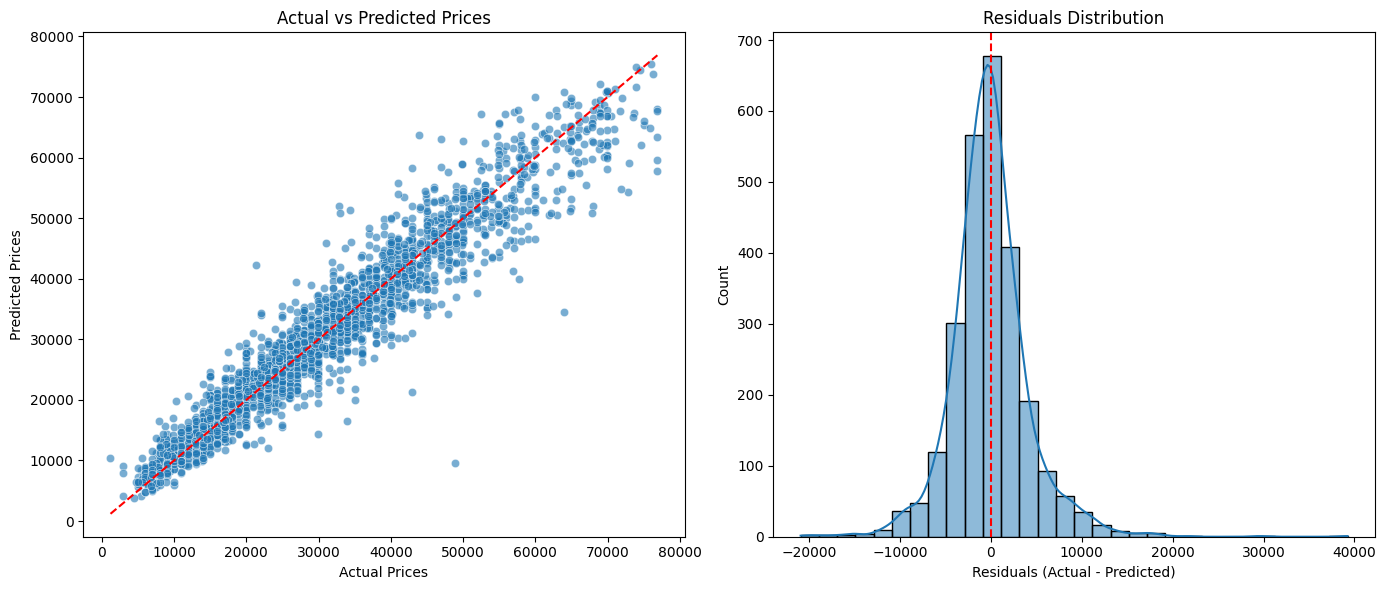

In [95]:
residuals = y_test - y_pred
plt.figure(figsize=(14, 6))
#1
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
#2
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=30)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Residuals (Actual - Predicted)")
plt.title("Residuals Distribution")
plt.tight_layout()
plt.show()